In [1]:
import numpy as np 
import pandas as pd 

In [2]:
data = pd.read_csv("cleaned_vulnerability_dataset.csv")

In [3]:
df = pd.DataFrame(data)

In [ ]:
print(df.head())

                                     vulnerable_code  \
0  project_loader: do not export empty environmen...   
1  __drm_atomic_helper_crtc_reset(crtc, &cstate->...   
2  "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3  var\tRemarkable = require('remarkable'),\npars...   
4  node.text if node\ncerts['signing'] << cert_no...   

                                          fixed_code  \
0  combined_paths = combine_paths(paths, prepend,...   
1  if (cstate)\n__drm_atomic_helper_crtc_reset(cr...   
2  "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3  var\tMarkdownIt = require('markdown-it'),\npar...   
4  Utils.element_text(node)\ncerts['signing'] << ...   

                                                file      language    pattern  
0                tests/unit/test_formatting_utils.py        python  injection  
1           drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c             c       file  
2  packages/plugin-ext/src/main/node/plugin-servi...    typescript  injection  
3     

In [ ]:
df.isna().sum()

vulnerable_code    0
fixed_code         0
file               0
language           0
pattern            0
dtype: int64

In [ ]:
df["pattern"].unique()

<ArrowStringArray>
[        'injection',              'file',               'xss',
     'sql_injection',           'CWE-352',              'auth',
   'deserialization',          'resource', 'command_injection',
             'error',            'crypto',     'data_exposure',
            'CWE-94',            'config',            'memory',
             'SHORT',           'network']
Length: 17, dtype: str

In [ ]:
df['language'].unique()

<StringArray>
[               'python',                     'c',            'typescript',
              'GDScript',          'Transact-SQL',                   'php',
                   'cpp',            'javascript',                 'scdoc',
                  'java',                  'html',                'Python',
             'Text only',                'Carbon',                'Genshi',
                    'go',                   'XML',      'XML+Django/Jinja',
           'Objective-C',                  'Perl',                   'ECL',
                  'ruby',               'verilog',                'QBasic',
       'Tera Term macro',             'Brainfuck',                'Scilab',
                   'css',               'Arduino',                 'MySQL',
        'JavaScript+PHP',               'XML+PHP',                'csharp',
        'ActionScript 3',             'CSS+Lasso',                 'Forth',
                'Matlab',                     'C',                  'SWIG'

In [ ]:
import sklearn

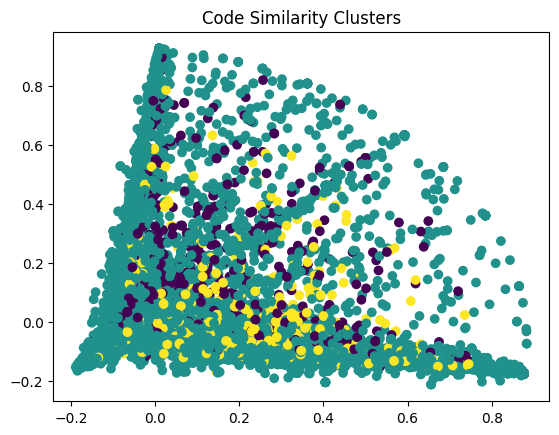

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load your data (assuming it's in a DataFrame)
# df = your dataframe

# Cluster vulnerable code snippets
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X = vectorizer.fit_transform(df['vulnerable_code'].fillna(''))

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['code_cluster'] = kmeans.fit_predict(X)

# Visualize
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
plt.scatter(coords[:, 0], coords[:, 1], c=df['code_cluster'])
plt.title('Code Similarity Clusters')
plt.show()

| Capability | Use Case |
|------------|----------|
| Semantic search | "Find code similar to this vulnerability" |
| Vulnerability classification | Cluster → predict vulnerability type |
| Fix pattern recommendation | Similar vulnerable code → suggest similar fixes |
| Anomaly detection | Code that doesn't fit any cluster |
| Few-shot learning | Use embeddings as features with limited labeled data |

In [ ]:
# Keep only rows where fixed_code is substantially different from vulnerable_code
df = df[df['fixed_code'].str.len() > 50]  # ignore very short "fixes"
df = df[~df['fixed_code'].str.contains(r'TEST|Bug #|--FILE--', case=False, na=False)]
df = df[df['vulnerable_code'].str.strip() != df['fixed_code'].str.strip()]

In [ ]:
df

,vulnerable_code,fixed_code,file,language,pattern
1,"__drm_atomic_helper_crtc_reset(crtc, &cstate->...",if (cstate)\n__drm_atomic_helper_crtc_reset(cr...,drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c,c,file
2,"""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...","""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...",packages/plugin-ext/src/main/node/plugin-servi...,typescript,injection
3,"var\tRemarkable = require('remarkable'),\npars...","var\tMarkdownIt = require('markdown-it'),\npar...",package.json,GDScript,file
4,node.text if node\ncerts['signing'] << cert_no...,Utils.element_text(node)\ncerts['signing'] << ...,test/responses/response_node_text_attack.xml.b...,Transact-SQL,injection
5,ld->bytes_left = ld->buffer_size - words*4;\n-,if (ld->buffer_size < words * 4)\nld->bytes_le...,libfaad/syntax.c,c,injection
...,...,...,...,...,...
25316,\nFix mispelling of the environmental variable...,Bernhard Herzog (Intevation) discovered that t...,intelmq-manager/php/controller.php,php,injection
25317,"N_(""unclosed quote"")\nint src, dst, count = 0,...","#define SPLIT_CMDLINE_ARGC_OVERFLOW 3\nN_(""unc...",alias.c,c,file
25318,if (eptr->numlines < line_idx)\n-,if (line_idx < 1 || line_idx > eptr->numlines)...,agent/mibgroup/agent/extend.c,c,resource
25319,await utils.run(`git clone ${remoteUrl} ${_tmp...,const { runWithSpawn } = require('./run');\naw...,src/index.js,javascript,injection


In [ ]:
print(df.head())

## aggressive filtering for makinng the good use of this dataset


In [6]:
# Add to your builder script
import re

junk_keywords = [
    r'--TEST--', r'--FILE--', r'--EXPECT--', r'Bug #\d+',
    r'Copyright', r'License', r'All rights reserved',
    r'#include\s*<', r'^\/\/', r'^/\*',  # comment-only lines
]

junk_re = re.compile('|'.join(junk_keywords), re.IGNORECASE)
df = df[~df['fixed_code'].astype(str).str.contains(junk_re, na=False)]

# Also require some code-like characters
df = df[df['fixed_code'].str.contains(r'[=\{\}\(\);]', na=False)]
df = df[df['vulnerable_code'].str.len() > 20]
df = df[df['fixed_code'].str.len() > 20]

In [5]:
print(df.head)

<bound method NDFrame.head of                                          vulnerable_code  \
0      project_loader: do not export empty environmen...   
1      __drm_atomic_helper_crtc_reset(crtc, &cstate->...   
2      "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3      var\tRemarkable = require('remarkable'),\npars...   
4      node.text if node\ncerts['signing'] << cert_no...   
...                                                  ...   
25316  \nFix mispelling of the environmental variable...   
25317  N_("unclosed quote")\nint src, dst, count = 0,...   
25318                  if (eptr->numlines < line_idx)\n-   
25319  await utils.run(`git clone ${remoteUrl} ${_tmp...   
25320  lxdui.jwt.secret.key = AC8d83&21Almnis710sds\n...   

                                              fixed_code  \
0      combined_paths = combine_paths(paths, prepend,...   
1      if (cstate)\n__drm_atomic_helper_crtc_reset(cr...   
2      "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3      va

In [7]:
# Add to your dataset cleaning script
import re

# Real junk patterns (adjust based on your samples)
junk_patterns = [
    r'Extra edits, patches, updates\.\.\.',
    r'Copyright \d{4}',
    r'All rights reserved',
    r'--TEST--', r'--FILE--', r'--EXPECT--',
    r'Bug #\d+', r'CVE-\d{4}',
    r'^[\d\.]+\s*$',  # just a version number
    r'^(Mingye Wang|John Doe|Patch by)',  # author names
]

# Remove rows matching any junk pattern
for pat in junk_patterns:
    df = df[~df['fixed_code'].str.contains(pat, case=False, na=False, regex=True)]

# Also remove rows with very short fixed_code (<30 chars) unless it's a clear fix
df = df[df['fixed_code'].str.len() >= 30]

print(f"After aggressive cleaning: {len(df)} rows")

After aggressive cleaning: 19250 rows


/tmp/ipykernel_33599/715075105.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df['fixed_code'].str.contains(pat, case=False, na=False, regex=True)]


In [14]:
df.to_csv('cleaned_vulnerability_dataset_filtered.csv', index=False)

In [9]:
#!/usr/bin/env python3
"""
Dataset Health Checker for vulnerable→fixed pairs (CSV)
Use this BEFORE building the vector DB.
"""

import pandas as pd
import re
from collections import Counter

# ========== CONFIG ==========
CSV_PATH = "/home/muhammad-taaha/code/repo-llm/rag/cleaned_vulnerability_dataset.csv"  # change to your actual path

# ========== 1. LOAD DATA ==========
df = pd.read_csv(CSV_PATH)
print(f"📊 Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

# ========== 2. SAMPLE RANDOM ROWS FOR MANUAL INSPECTION ==========
print("\n🔎 Random sample (10 rows) – manually verify fixes look real:")
sample = df.sample(min(10, len(df)))
for i, row in sample.iterrows():
    print(f"\n--- Row {i} ---")
    print(f"Pattern: {row.get('pattern', '?')} | Language: {row.get('language', '?')}")
    print(f"Vulnerable: {row['vulnerable_code'][:150]}...")
    print(f"Fixed:      {row['fixed_code'][:150]}...")

# ========== 3. DETECT JUNK IN fixed_code ==========
junk_patterns = [
    r'--TEST--', r'--FILE--', r'--EXPECT--', r'Bug #\d+', r'CVE-\d{4}',
    r'Copyright', r'License', r'All rights reserved',
    r'#include\s*<', r'^\/\/.*$', r'^/\*.*\*/$',  # comment-only lines
    r'^[\d\.]+\s',  # version numbers
    r'<(\w+)[^>]*>.*</\1>',  # HTML tags (maybe okay for XSS, but flag)
]

junk_re = re.compile('|'.join(junk_patterns), re.IGNORECASE)
junk_rows = df[df['fixed_code'].astype(str).str.contains(junk_re, na=False)]
print(f"\n🚨 Rows with potential junk in fixed_code: {len(junk_rows)} ({len(junk_rows)/len(df)*100:.1f}%)")
if len(junk_rows) > 0:
    print("Sample junk entries:")
    for idx, row in junk_rows.head(3).iterrows():
        print(f"  - {row['fixed_code'][:100]}")

# ========== 4. CHECK FOR IDENTICAL VULNERABLE AND FIXED ==========
identical = df[df['vulnerable_code'].str.strip() == df['fixed_code'].str.strip()]
print(f"\n🔄 Rows where vulnerable == fixed (useless): {len(identical)}")

# ========== 5. CODE LENGTH ANALYSIS ==========
df['vuln_len'] = df['vulnerable_code'].astype(str).str.len()
df['fixed_len'] = df['fixed_code'].astype(str).str.len()

too_short_vuln = df[df['vuln_len'] < 20]
too_short_fixed = df[df['fixed_len'] < 20]
print(f"\n📏 Vulnerable code <20 chars: {len(too_short_vuln)}")
print(f"📏 Fixed code <20 chars: {len(too_short_fixed)}")

# ========== 6. DISTRIBUTION BY PATTERN AND LANGUAGE ==========
print("\n📊 Pattern distribution:")
pattern_counts = df['pattern'].value_counts()
for pat, cnt in pattern_counts.head(10).items():
    print(f"   {pat}: {cnt}")

print("\n📊 Language distribution:")
lang_counts = df['language'].value_counts()
for lang, cnt in lang_counts.head(10).items():
    print(f"   {lang}: {cnt}")

# ========== 7. CHECK FOR MISSING VALUES ==========
missing = df[['vulnerable_code', 'fixed_code']].isnull().sum()
print(f"\n🔍 Missing values: vulnerable={missing['vulnerable_code']}, fixed={missing['fixed_code']}")

# ========== 8. FINAL VERDICT ==========
print("\n" + "="*60)
print("🏁 HEALTH CHECK VERDICT")
print("="*60)

issues = []
if len(junk_rows) > len(df) * 0.05:
    issues.append(f"❌ {len(junk_rows)/len(df)*100:.1f}% junk in fixed_code – clean more aggressively")
if len(identical) > 100:
    issues.append(f"❌ {len(identical)} rows have identical vulnerable/fixed – remove them")
if len(too_short_fixed) > 1000:
    issues.append(f"❌ {len(too_short_fixed)} rows have very short fixed_code (<20 chars)")

if issues:
    print("⚠️  Issues found:")
    for issue in issues:
        print(f"   {issue}")
    print("\n👉 Recommended: Apply stricter filters and rebuild CSV.")
else:
    print("✅ Dataset looks clean! You can proceed to build the vector DB.")
    print(f"   {len(df)} rows, {pattern_counts.shape[0]} pattern types, {lang_counts.shape[0]} languages.")

# Optional: remove problematic rows if you want a clean export
clean_df = df[
    ~df['fixed_code'].astype(str).str.contains(junk_re, na=False) &
    (df['vulnerable_code'].str.strip() != df['fixed_code'].str.strip()) &
    (df['fixed_len'] >= 20)
]
print(f"\n🧹 If you export this cleaned subset: {len(clean_df)} rows remain.")

📊 Total rows: 25321
Columns: ['vulnerable_code', 'fixed_code', 'file', 'language', 'pattern']

🔎 Random sample (10 rows) – manually verify fixes look real:

--- Row 12302 ---
Pattern: xss | Language: php
Vulnerable: Fix a regression where some contact data was missing in export and PHP warnings were logged (Kolab #4522)
return $tag == 'a' && $attr == 'href';
-...
Fixed:      - Fix XSS issue in href attribute on area tag (#5240)

return ($tag == 'a' || $tag == 'area') && $attr == 'href';
/**
* Test XSS in area's href (#5240...

--- Row 25002 ---
Pattern: injection | Language: java
Vulnerable: byte[] rest = new byte[restLen];
rest[got++] = (byte) ch;
byte[] linkArray = new byte[(int) ZipLong.getValue(tmp, 2)];

if (linkArray.length == 0) {
S...
Fixed:      ByteArrayOutputStream bos = new ByteArrayOutputStream();
bos.write((byte) ch);
got++;
bos.close();
"Paxheader. Expected "
" bytes, read "
got);
byte[]...

--- Row 762 ---
Pattern: injection | Language: c
Vulnerable: status=SetQuantumPa

/tmp/ipykernel_30276/3480090099.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  junk_rows = df[df['fixed_code'].astype(str).str.contains(junk_re, na=False)]



🚨 Rows with potential junk in fixed_code: 5598 (22.1%)
Sample junk entries:
  - combined_paths = combine_paths(paths, prepend, separator)

if separator.isspace():
formatted = f'{en
  - enum { AVX512BlockSize = 512 };
/* max integer logarithm over a range of AVX512BlockSize integers (5
  - Extra edits, patches, updates... (2013...,2019)
Mingye Wang
- 2019-Jul-31
* Libspiro Version 2019073

🔄 Rows where vulnerable == fixed (useless): 0

📏 Vulnerable code <20 chars: 403
📏 Fixed code <20 chars: 118

📊 Pattern distribution:
   injection: 13480
   file: 2509
   xss: 2336
   auth: 2048
   sql_injection: 1206
   resource: 1160
   command_injection: 639
   crypto: 437
   data_exposure: 364
   deserialization: 335

📊 Language distribution:
   c: 6762
   php: 3553
   python: 1835
   javascript: 1561
   java: 1451
   GDScript: 1269
   go: 1200
   Transact-SQL: 986
   cpp: 823
   ruby: 738

🔍 Missing values: vulnerable=0, fixed=0

🏁 HEALTH CHECK VERDICT
⚠️  Issues found:
   ❌ 22.1% junk in fixed_c

/tmp/ipykernel_30276/3480090099.py:97: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df['fixed_code'].astype(str).str.contains(junk_re, na=False) &



🧹 If you export this cleaned subset: 19607 rows remain.


In [13]:
# After loading df
import re

# Keep rows where vulnerable_code looks like real code (not plain text)
code_indicators = r'[\=\{\}\(\)\[\]\;\:\,\.]'  # common code punctuation
df = df[df['vulnerable_code'].str.contains(code_indicators, na=False, regex=True)]
df = df[df['fixed_code'].str.contains(code_indicators, na=False, regex=True)]

# Exclude rows with version/changelog patterns
changelog_patterns = [
    r'\* Changes in', r'^[\-\*]\s+\w+ \d{4}',  # bullet points with year
    r'^(fix|update|release|patch|bump|version)\s+\d',  # commit-ish messages
    r'^\s*#.*$'  # comment-only lines (allow if mixed, but drop if only comments)
]
changelog_re = re.compile('|'.join(changelog_patterns), re.IGNORECASE)
df = df[~df['vulnerable_code'].str.contains(changelog_re, na=False)]
df = df[~df['fixed_code'].str.contains(changelog_re, na=False)]

# Optional: require that code contains a function definition or statement
code_keywords = r'\b(function|def|class|if|for|while|return|import|require|public|private)\b'
df = df[df['vulnerable_code'].str.contains(code_keywords, na=False, regex=True)]

print(f"After code‑based cleaning: {len(df)} rows")

/tmp/ipykernel_33599/503417939.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df['vulnerable_code'].str.contains(changelog_re, na=False)]
/tmp/ipykernel_33599/503417939.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df['fixed_code'].str.contains(changelog_re, na=False)]


After code‑based cleaning: 11856 rows


/tmp/ipykernel_33599/503417939.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[df['vulnerable_code'].str.contains(code_keywords, na=False, regex=True)]


In [15]:
#!/usr/bin/env python3
import pandas as pd
import re

# ========== CONFIG ==========
CSV_PATH = "/home/muhammad-taaha/code/repo-llm/rag/cleaned_vulnerability_dataset_filtered.csv"  # adjust to your filtered file

# ========== LOAD ==========
df = pd.read_csv(CSV_PATH)
print(f"✅ Loaded {len(df)} rows")

# ========== SAMPLE INSPECTION ==========
print("\n🔎 Random sample (5 rows):")
for i, row in df.sample(5).iterrows():
    print(f"\n--- Row {i} ---")
    print(f"Pattern: {row.get('pattern','?')} | Language: {row.get('language','?')}")
    print(f"Vulnerable: {row['vulnerable_code'][:120]}...")
    print(f"Fixed:      {row['fixed_code'][:120]}...")

# ========== JUNK DETECTION (aggressive) ==========
junk_patterns = [
    r'--TEST--', r'--FILE--', r'--EXPECT--', r'Bug #\d+', r'CVE-\d{4}',
    r'Copyright', r'License', r'All rights reserved',
    r'Extra edits, patches, updates\.\.\.', r'Mingye Wang',
    r'^[\d\.]+\s*$',  # just version number
]
junk_re = re.compile('|'.join(junk_patterns), re.IGNORECASE)
junk_rows = df[df['fixed_code'].astype(str).str.contains(junk_re, na=False)]
print(f"\n🚨 Potential junk rows: {len(junk_rows)} ({len(junk_rows)/len(df)*100:.2f}%)")

# ========== IDENTICAL VULN/FIXED ==========
identical = df[df['vulnerable_code'].str.strip() == df['fixed_code'].str.strip()]
print(f"🔄 Vulnerable == Fixed: {len(identical)}")

# ========== LENGTH CHECKS ==========
df['fixed_len'] = df['fixed_code'].astype(str).str.len()
short_fixed = df[df['fixed_len'] < 30]
print(f"📏 Fixed code <30 chars: {len(short_fixed)} ({len(short_fixed)/len(df)*100:.2f}%)")

# ========== PATTERN DISTRIBUTION ==========
print("\n📊 Top patterns:")
for pat, cnt in df['pattern'].value_counts().head(8).items():
    print(f"   {pat}: {cnt}")

# ========== FINAL VERDICT ==========
print("\n" + "="*60)
print("🏁 HEALTH CHECK VERDICT")
print("="*60)
if len(junk_rows) > len(df) * 0.05:
    print(f"⚠️  {len(junk_rows)/len(df)*100:.1f}% junk still present – consider more filtering")
else:
    print("✅ Junk level acceptable (<5%)")
if len(short_fixed) > len(df) * 0.1:
    print(f"⚠️  {len(short_fixed)/len(df)*100:.1f}% very short fixes – may be useless")
else:
    print("✅ Short fixes acceptable")
if len(identical) > 0:
    print(f"⚠️  {len(identical)} identical vulnerable/fixed rows – remove them")
else:
    print("✅ No identical rows")

print(f"\n👉 Total clean rows for vector DB: {len(df) - len(junk_rows) - len(identical) - len(short_fixed)} (approx)")
print("If verdict is mostly ✅, rebuild vector DB with this CSV.")

✅ Loaded 11856 rows

🔎 Random sample (5 rows):

--- Row 6990 ---
Pattern: file | Language: c
Vulnerable: child = jspNewPrototype(objName);
if (jsvHasChildren(parent)) {
/// Create a new Class of the given instance and return ...
Fixed:      Fix potential corruption issue caused by `delete [].__proto__` (fix #2142)
JsVar *p = jsvSkipNameAndUnLock(jspNewPrototy...

--- Row 9267 ---
Pattern: injection | Language: php
Vulnerable: "POT-Creation-Date: 2012-07-12 11:43+0300\n"
"PO-Revision-Date: 2012-07-12 11:43+0300\n"
#: twitter.php:244
#: twitter.p...
Fixed:      msgid ""
msgstr ""
"Project-Id-Version: twitter\n"
"Report-Msgid-Bugs-To: \n"
"POT-Creation-Date: 2012-07-24 20:03+0300\...

--- Row 7135 ---
Pattern: auth | Language: XML+PHP
Vulnerable: $view->success = false;
// TODO is the error on the view used somewhere?
$view->error = 'user inactive';
$view->error = ...
Fixed:      use Pimcore\Logger;
$error = null;
$error = 'user inactive';
$error = 'user has no email address';
$error = 'u

In [16]:
#!/usr/bin/env python3
import pandas as pd
import re

CSV_PATH = "/home/muhammad-taaha/code/repo-llm/rag/cleaned_vulnerability_dataset_filtered.csv"  # adjust

df = pd.read_csv(CSV_PATH)
print(f"Total rows: {len(df)}")

# 1. Check for code-like characters (must have at least one of these)
code_chars = r'[{}()\[\];=<>+\-*/&|!~]'
df['has_code_chars'] = df['fixed_code'].str.contains(code_chars, na=False, regex=True)

# 2. Suspicious patterns: commit messages, version logs, copyright, PO files, etc.
suspicious_patterns = [
    r'^(fix|update|bump|release|patch|version|merge|chore|docs?):?\s',  # commit messages
    r'Copyright\s+\d{4}',
    r'^#!\s*/usr/bin/',
    r'--TEST--', r'--FILE--', r'--EXPECT',
    r'msgid\s+"',           # PO file entries
    r'msgstr\s+"',
    r'^Project-Id-Version:',
    r'^\*\s+\w+\s+\d{4}',   # bullet changelog
    r'^[\d\.]+\s+[\d\-:]+', # timestamps
    r'Signed-off-by:', r'Reviewed-by:',
    r'^#\s*(TODO|FIXME|NOTE):',  # comments only
]
suspicious_re = re.compile('|'.join(suspicious_patterns), re.IGNORECASE | re.MULTILINE)
df['has_suspicious'] = df['fixed_code'].astype(str).apply(lambda x: bool(suspicious_re.search(x)))

# 3. Also check vulnerable_code for same issues
df['vuln_suspicious'] = df['vulnerable_code'].astype(str).apply(lambda x: bool(suspicious_re.search(x)))

# 4. Check for "natural language only" – many words and few code chars
word_count = df['fixed_code'].astype(str).str.split().str.len()
df['word_count'] = word_count
df['likely_natural_language'] = (word_count > 15) & (~df['has_code_chars'])

# Combine flags
junk_flag = (df['likely_natural_language'] | df['has_suspicious'] | df['vuln_suspicious'])
junk_rows = df[junk_flag]

print(f"\n🚨 Rows flagged as likely junk: {len(junk_rows)} ({len(junk_rows)/len(df)*100:.2f}%)")

if len(junk_rows) > 0:
    print("\n📋 Sample junk rows (first 5):")
    for idx, row in junk_rows.head(5).iterrows():
        print(f"\n--- Row {idx} ---")
        print(f"Pattern: {row.get('pattern','?')} | Language: {row.get('language','?')}")
        print(f"Fixed preview: {row['fixed_code'][:200]}...")
        print(f"Flags: text={row['likely_natural_language']}, susp={row['has_suspicious']}, vuln_susp={row['vuln_suspicious']}")

# Summary
print("\n📊 Summary:")
print(f"  - Has code characters: {df['has_code_chars'].sum()}/{len(df)}")
print(f"  - Likely natural language only: {df['likely_natural_language'].sum()}")
print(f"  - Suspicious patterns in fixed_code: {df['has_suspicious'].sum()}")
print(f"  - Suspicious patterns in vulnerable_code: {df['vuln_suspicious'].sum()}")

# Final verdict
threshold = len(df) * 0.10  # 10%
if len(junk_rows) > threshold:
    print(f"\n⚠️ {len(junk_rows)/len(df)*100:.1f}% junk detected – recommend filtering these rows out before building DB.")
    print("   Run: df_clean = df[~junk_flag] ; df_clean.to_csv('clean_final.csv', index=False)")
else:
    print(f"\n✅ Only {len(junk_rows)/len(df)*100:.1f}% flagged – dataset is clean enough for vector DB rebuild.")

Total rows: 11856

🚨 Rows flagged as likely junk: 782 (6.60%)

📋 Sample junk rows (first 5):

--- Row 25 ---
Pattern: CWE-352 | Language: python
Fixed preview: """
Return a dictionary parsed from a `Cookie:` header string.
"""
if six.PY2:
cookie = force_str(cookie)
for chunk in cookie.split(str(';')):
if str('=') in chunk:
key, val = chunk.split(str('='), 1)...
Flags: text=False, susp=True, vuln_susp=False

--- Row 30 ---
Pattern: file | Language: ruby
Fixed preview: VERSION = "2.6.14.1"
owners = Gem::SafeYAML.load resp.body
mkdir_p_safe mkdir, mkdir_options, destination_dir, entry.full_name
destination_dir = realpath destination_dir
destination.start_with? destin...
Flags: text=False, susp=True, vuln_susp=True

--- Row 52 ---
Pattern: sql_injection | Language: Objective-C
Fixed preview: ## [v2.0.0] - 2020-06-17

### Added
- Adds password authentication for the backend Postgres database connection.
- Adds TLS support between the Conjur pod and the Postgres pod.
- Adds default auto-gen.